# 집계: 최소, 최대 및 그 사이의 모든 것

데이터 세트를 탐색하는 첫 번째 단계는 다양한 요약 통계를 계산하는 것입니다.
아마도 가장 일반적인 요약 통계는 데이터 세트의 "일반적인" 값을 요약할 수 있는 평균 및 표준 편차일 것입니다. 그러나 다른 집계도 유용합니다(합계, 곱, 중앙값, 최소값 및 최대값, 분위수 등).

NumPy에는 배열 작업을 위한 빠른 내장 집계 기능이 있습니다. 여기서는 그 중 일부에 대해 논의하고 시험해 보겠습니다.

## 배열의 값 합산

간단한 예로 배열에 있는 모든 값의 합계를 계산하는 것을 고려해 보세요.
파이썬(Python) 자체에서는 내장 `sum` 함수를 사용하여 이 작업을 수행할 수 있습니다.

In [1]:
import numpy as np
rng = np.random.default_rng()

In [2]:
L = rng.random(100)
sum(L)

52.76825337322368

구문은 NumPy의 'sum' 함수와 매우 유사하며 가장 간단한 경우에도 결과는 동일합니다.

In [3]:
np.sum(L)

52.76825337322366

그러나 컴파일된 코드에서 작업을 실행하기 때문에 NumPy의 작업 버전은 훨씬 더 빠르게 계산됩니다.

In [4]:
big_array = rng.random(1000000)
%timeit sum(big_array)
%timeit np.sum(big_array)

89.9 ms ± 233 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
521 µs ± 8.37 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


하지만 주의하세요: `sum` 함수와 `np.sum` 함수는 동일하지 않으므로 때로는 혼란을 초래할 수 있습니다!
특히, 선택적 인수는 서로 다른 의미를 갖습니다(`sum(x, 1)`는 합계를 `1`에서 초기화하고 `np.sum(x, 1)`은 `1` 축을 따라 합계를 초기화합니다). 그리고 `np.sum`은 다음 섹션에서 볼 수 있듯이 여러 배열 차원을 인식합니다.

## 최소 및 최대

마찬가지로 파이썬(Python)에는 주어진 배열의 최소값과 최대값을 찾는 데 사용되는 'min' 및 'max' 함수가 내장되어 있습니다.

In [5]:
min(big_array), max(big_array)

(2.0114398036064074e-07, 0.9999997912802653)

NumPy의 해당 함수는 비슷한 구문을 가지며 훨씬 더 빠르게 작동합니다.

In [6]:
np.min(big_array), np.max(big_array)

(2.0114398036064074e-07, 0.9999997912802653)

In [7]:
%timeit min(big_array)
%timeit np.min(big_array)

72 ms ± 177 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
564 µs ± 3.11 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


`min`, `max`, `sum` 및 기타 여러 NumPy 집계의 경우 더 짧은 구문은 배열 객체 자체의 메서드를 사용하는 것입니다.

In [8]:
print(big_array.min(), big_array.max(), big_array.sum())

2.0114398036064074e-07 0.9999997912802653 499854.0273321711


가능할 때마다 NumPy 배열에서 작업할 때 이러한 집계의 NumPy 버전을 사용하고 있는지 확인하세요!

### 다차원 집계

일반적인 집계 작업 유형 중 하나는 행이나 열에 따른 집계입니다.
2차원 배열에 일부 데이터가 저장되어 있다고 가정해 보겠습니다.

In [9]:
M = rng.integers(0, 10, (3, 4))
print(M)

[[0 3 1 2]
 [1 9 7 0]
 [4 8 3 7]]


NumPy 집계는 다차원 배열의 모든 요소에 적용됩니다.

In [10]:
M.sum()

45

집계 함수는 집계가 계산되는 *축*을 지정하는 추가 인수를 사용합니다. 예를 들어 `axis=0`을 지정하면 각 열 내에서 최소값을 찾을 수 있습니다.

In [11]:
M.min(axis=0)

array([0, 3, 1, 0])

이 함수는 4개의 숫자 열에 해당하는 4개의 값을 반환합니다.

마찬가지로 각 행 내에서 최대값을 찾을 수 있습니다.

In [12]:
M.max(axis=1)

array([3, 9, 8])

여기서 축이 지정되는 방식은 다른 언어를 사용하는 사용자에게 혼란을 줄 수 있습니다.
`axis` 키워드는 반환될 차원이 아니라 *축소*될 배열의 차원을 지정합니다.
따라서 `axis=0`을 지정하면 축 0이 축소된다는 의미입니다. 2차원 배열의 경우 각 열 내의 값이 집계됩니다.

### 기타 집계 함수

NumPy는 유사한 API를 사용하여 여러 다른 집계 함수를 제공하며, 추가로 대부분은 특수 IEEE 부동 소수점 'NaN' 값으로 표시되는 누락된 값을 무시하면서 결과를 계산하는 'NaN' 안전한 대응 기능을 제공합니다([누락된 데이터 처리](03.04-Missing-Values.ipynb) 참조).

다음 표는 NumPy에서 사용할 수 있는 유용한 집계 함수 목록을 제공합니다.

|함수 이름 |   NaN 안전 버전| 설명 |
|----|------|----------------------------------|
| `np.sum` | `np.nansum` | 요소의 합 계산 |
| `np.prod` | `np.nanprod` | 요소의 곱을 계산 |
| `np.mean` | `np.nanmean` | 요소의 평균 계산 |
| `np.std` | `np.nanstd` | 표준편차 계산 |
| `np.var` | `np.nanvar` | 분산 계산 |
| `np.my` | `np.nanmin` | 최소값 찾기 |
| `np.max` | `np.nanmax` | 최대값 찾기 |
| `np.argmin` | `np.nanargmin` | 최소값 인덱스 찾기 |
| `np.argmax` | `np.nanargmax` | 최대값 인덱스 찾기 |
| `np.median` | `np.nanmedian` | 요소의 중앙값 계산 |
| `np.백분위수` | `np.nanpercentile`| 요소의 순위 기반 통계 계산 |
| `np.any` | 해당 없음 | 요소가 참인지 평가 |
| `np.all` | 해당 없음 | 모든 요소가 참인지 평가 |

이 책의 나머지 부분 전체에서 이러한 집계를 자주 살펴볼 수 있습니다.

## 예: 미국 대통령의 평균 키는 얼마입니까?

NumPy에서 사용 가능한 집계는 값 집합에 대한 요약 통계 역할을 할 수 있습니다.
작은 예로 모든 미국 대통령의 키를 생각해 봅시다.
이 데이터는 쉼표로 구분된 레이블 및 값 목록인 *president_heights.csv* 파일에서 사용할 수 있습니다.

In [13]:
!head -4 data/president_heights.csv

order,name,height(cm)
1,George Washington,189
2,John Adams,170
3,Thomas Jefferson,189


[3부](03.00-Introduction-to-Pandas.ipynb)에서 더 자세히 살펴볼 Pandas 패키지를 사용하여 파일을 읽고 이 정보를 추출합니다(높이는 센티미터 단위로 측정됩니다).

In [14]:
import pandas as pd
data = pd.read_csv('data/president_heights.csv')
heights = np.array(data['height(cm)'])
print(heights)

[189 170 189 163 183 171 185 168 173 183 173 173 175 178 183 193 178 173
 174 183 183 168 170 178 182 180 183 178 182 188 175 179 183 193 182 183
 177 185 188 188 182 185 191 182]


이제 이 데이터 배열이 있으므로 다양한 요약 통계를 계산할 수 있습니다.

In [15]:
print("Mean height:       ", heights.mean())
print("Standard deviation:", heights.std())
print("Minimum height:    ", heights.min())
print("Maximum height:    ", heights.max())

Mean height:        180.04545454545453
Standard deviation: 6.983599441335736
Minimum height:     163
Maximum height:     193


각 경우에 집계 작업은 전체 배열을 단일 요약 값으로 축소하여 값 분포에 대한 정보를 제공합니다.
분위수를 계산할 수도 있습니다:

In [16]:
print("25th percentile:   ", np.percentile(heights, 25))
print("Median:            ", np.median(heights))
print("75th percentile:   ", np.percentile(heights, 75))

25th percentile:    174.75
Median:             182.0
75th percentile:    183.5


우리는 미국 대통령의 평균 키가 182cm, 즉 6피트에 조금 못 미치는 것을 확인할 수 있습니다.

물론 때로는 Matplotlib의 도구를 사용하여 수행할 수 있는 이 데이터의 시각적 표현을 보는 것이 더 유용할 수 있습니다(Matplotlib에 대한 자세한 내용은 [4부](04.00-Introduction-To-Matplotlib.ipynb)에서 논의하겠습니다). 예를 들어 이 코드는 다음 차트를 생성합니다.

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

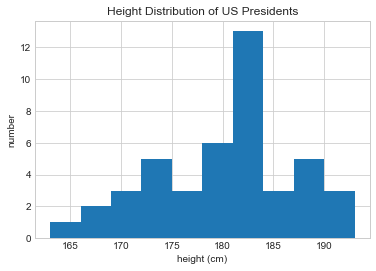

In [18]:
plt.hist(heights)
plt.title('Height Distribution of US Presidents')
plt.xlabel('height (cm)')
plt.ylabel('number');